/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


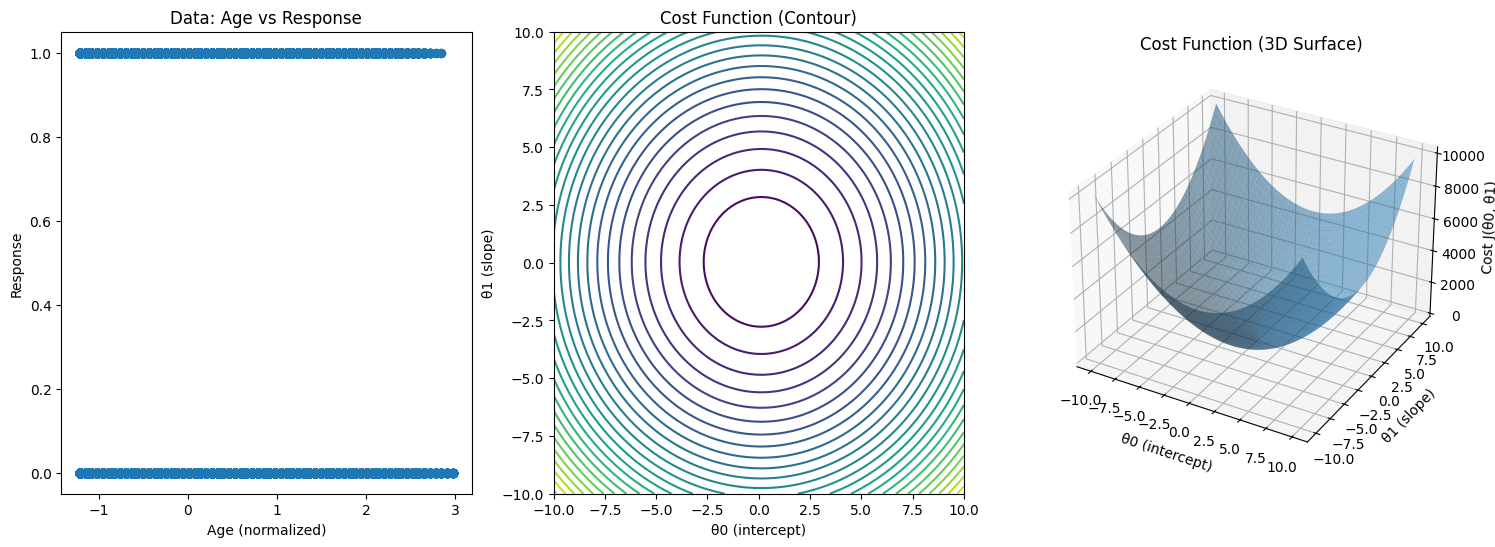

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import animation

# ----------------------------
# LOAD YOUR DATA
# ----------------------------
df = pd.read_csv("/content/data.csv")

# Use Age -> Response
X_raw = df["Age"].values
y = df["Response"].values

# Normalize (IMPORTANT)
X_raw = (X_raw - X_raw.mean()) / X_raw.std()

m = len(X_raw)

# Add bias term
X = np.c_[np.ones(m), X_raw]

# ----------------------------
# COST SURFACE (for visualization)
# ----------------------------
t0 = np.linspace(-10, 10, 100)
t1 = np.linspace(-10, 10, 100)
T0, T1 = np.meshgrid(t0, t1)
cost_surface = np.zeros_like(T0)

def compute_cost(theta):
    return (1/(2*m)) * np.sum((X @ theta - y) ** 2)

for i in range(len(t0)):
    for j in range(len(t1)):
        theta_tmp = np.array([T0[i,j], T1[i,j]])
        cost_surface[i,j] = compute_cost(theta_tmp) * 100

# ----------------------------
# GRADIENT DESCENT
# ----------------------------
theta = np.array([0.0, 0.0])
lr = 0.01
epochs = 50

theta_hist = []
cost_hist = []

for i in range(epochs):
    gradients = (1/m) * (X.T @ (X @ theta - y))
    theta = theta - lr * gradients

    theta_hist.append(theta.copy())
    cost_hist.append(compute_cost(theta))

    # print(min(cost_hist), max(cost_hist))

theta_hist = np.array(theta_hist)

# ----------------------------
# VISUALIZATION SETUP
# ----------------------------
fig = plt.figure(figsize=(18,6))

# 1. Data + Fit
ax1 = fig.add_subplot(1,3,1)
ax1.scatter(X[:,1], y)
line, = ax1.plot([], [])
ax1.set_xlabel("Age (normalized)")
ax1.set_ylabel("Response")
ax1.set_title("Data: Age vs Response")

# 2. Contour
ax2 = fig.add_subplot(1,3,2)
ax2.contour(T0, T1, cost_surface, levels=30)
point2, = ax2.plot([], [], 'ro')
path2, = ax2.plot([], [], 'r-')
ax2.set_xlabel("θ0 (intercept)")
ax2.set_ylabel("θ1 (slope)")
ax2.set_title("Cost Function (Contour)")

# 3. 3D Surface
ax3 = fig.add_subplot(1,3,3, projection='3d')
ax3.plot_surface(T0, T1, cost_surface, alpha=0.5)
point3, = ax3.plot([], [], [], 'ro')
path3, = ax3.plot([], [], [], 'r-')
ax3.set_xlabel("θ0 (intercept)")
ax3.set_ylabel("θ1 (slope)")
ax3.set_zlabel("Cost J(θ0, θ1)")
ax3.set_title("Cost Function (3D Surface)")

# ----------------------------
# ANIMATION FUNCTION
# ----------------------------
def animate(i):
    theta = theta_hist[i]

    # Line fit
    x_vals = np.array([-2, 2])
    y_vals = theta[0] + theta[1]*x_vals
    line.set_data(x_vals, y_vals)

    # Contour update
    point2.set_data(theta[0], theta[1])
    path2.set_data(theta_hist[:i+1,0], theta_hist[:i+1,1])

    # 3D update
    z = cost_hist[i]
    point3.set_data(theta[0], theta[1])
    point3.set_3d_properties(z)

    path3.set_data(theta_hist[:i+1,0], theta_hist[:i+1,1])
    path3.set_3d_properties(cost_hist[:i+1])

    return line, point2, path2, point3, path3

anim = animation.FuncAnimation(fig, animate, frames=epochs, interval=300)

plt.show()